### This notebook is used to verify if the random generated scanpath used for baseline is valid

We first want to find all possible length of the dataset

Script that get all possible vector length from EMIP dataset for trial 2

In [6]:
# Addjust the trial number if needed
!cd ../../../ && dir && python -m Code.src.tools.scripts.get_all_vec_length

^C


 Volume in drive D is Data
 Volume Serial Number is 1222-8933

 Directory of d:\Storage\ETH\Thesis

2025/11/25  14:39    <DIR>          .
2025/10/15  14:36    <DIR>          ..
2025/11/25  15:04    <DIR>          .venv
2025/11/25  15:28    <DIR>          Code
2025/10/13  15:59    <DIR>          python
               0 File(s)              0 bytes
               5 Dir(s)  558,454,222,848 bytes free
Parsing experiment: 1 from file: 1_rawdata.tsv
parsing file: 1_rawdata.tsv
Parsing experiment: 2 from file: 2_rawdata.tsv
parsing file: 2_rawdata.tsv
Parsing experiment: 3 from file: 3_rawdata.tsv
parsing file: 3_rawdata.tsv
Parsing experiment: 4 from file: 4_rawdata.tsv
parsing file: 4_rawdata.tsv
Parsing experiment: 5 from file: 5_rawdata.tsv
parsing file: 5_rawdata.tsv
Parsing experiment: 6 from file: 6_rawdata.tsv
parsing file: 6_rawdata.tsv
Parsing experiment: 7 from file: 7_rawdata.tsv
parsing file: 7_rawdata.tsv
Parsing experiment: 8 from file: 8_rawdata.tsv
parsing file: 8_rawdata.tsv

Do the import for following code

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import os

from tools.path import setup_paths
paths = setup_paths()

The script fit the length data to normal, lognormal and gamma distribution and pick the model which fitted best. After that it generate $k$ samples of scanpath similarity from multimatch.

In [ ]:
# Addjust the number of samples (k) if needed
!cd ../../../ && python -m Code.src.tools.scripts.gen_rand_mm_dataset

^C


In [ ]:
dimensions = ['Shape', 'Direction', 'Length', 'Position', 'Duration']

random_mm_result_path = os.path.join(paths['output_path'], "dataset", "rand_mm_dataset.csv")
random_mm_result = pd.read_csv(random_mm_result_path)

for dim in dimensions:
    print(dim.center(20, '='))
    print("Mean:", np.mean(random_mm_result[dim]))
    print("Std Dev:", np.std(random_mm_result[dim]))
    print("Median:", np.median(random_mm_result[dim]), "\n")

=======Shape========
Mean: 0.8717327995090111
Std Dev: 0.010441347437556753
Median: 0.8736838019736146 

=====Direction======
Mean: 0.7283006325877497
Std Dev: 0.07669846765466422
Median: 0.7546052612749019 

=======Length=======
Mean: 0.8558236900797144
Std Dev: 0.031017019604287238
Median: 0.8666419883053571 

======Position======
Mean: 0.7528101672983101
Std Dev: 0.026647738224616357
Median: 0.7574567708226458 

======Duration======
Mean: 0.8344252494076397
Std Dev: 0.015984929709965123
Median: 0.8357606902980651 



Visualize random_mm_result

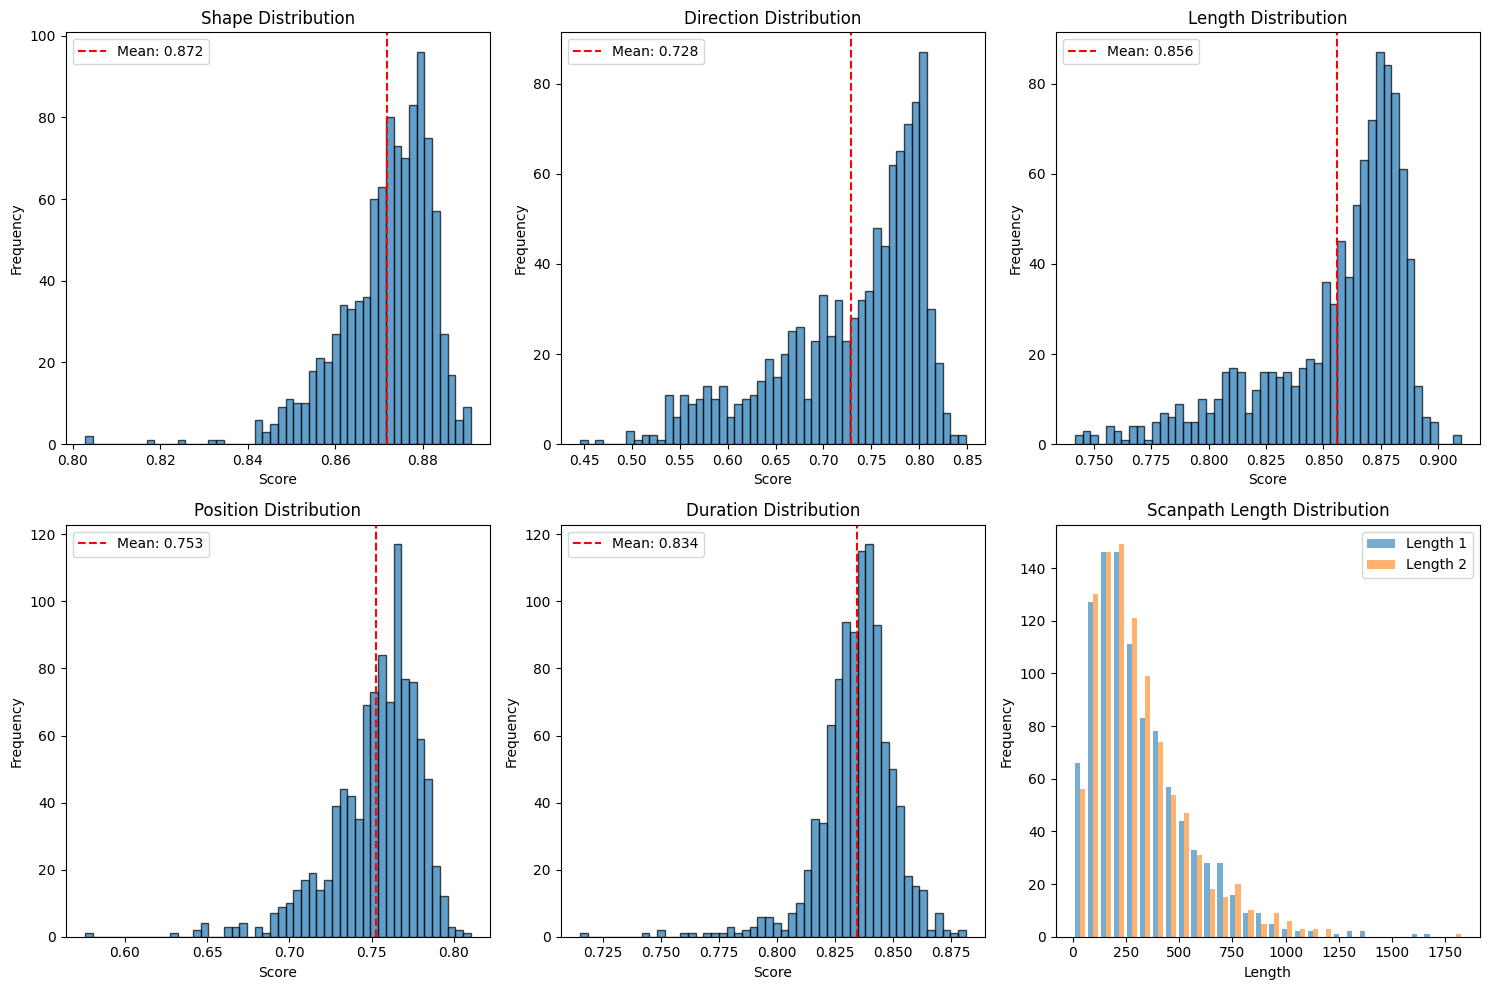

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, dim in enumerate(dimensions):
    axes[idx].hist(random_mm_result[dim], bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{dim} Distribution')
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(np.mean(random_mm_result[dim]), color='red', 
                      linestyle='--', label=f'Mean: {np.mean(random_mm_result[dim]):.3f}')
    axes[idx].legend()

# 长度分布
axes[5].hist([random_mm_result['length_1'], random_mm_result['length_2']], 
             bins=30, alpha=0.6, label=['Length 1', 'Length 2'])
axes[5].set_title('Scanpath Length Distribution')
axes[5].set_xlabel('Length')
axes[5].set_ylabel('Frequency')
axes[5].legend()

plt.tight_layout()
plt.show()


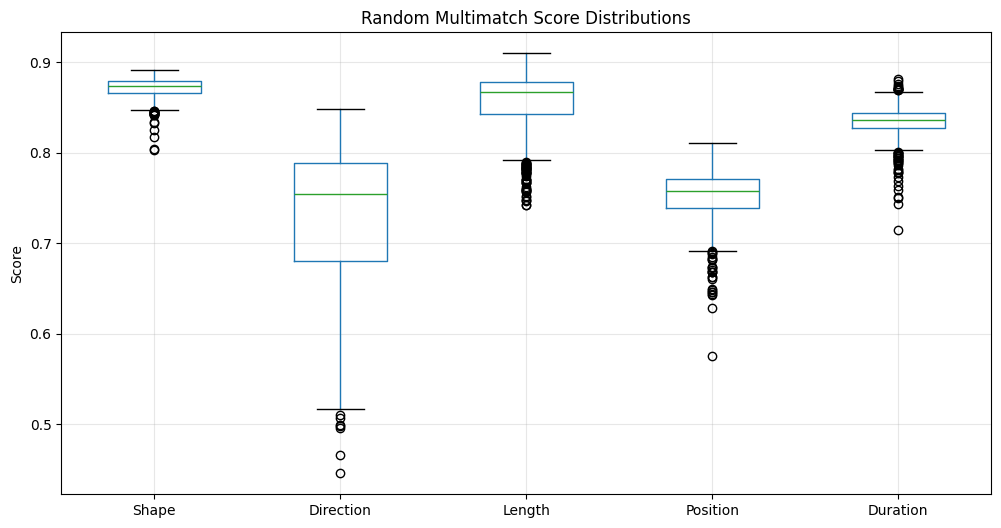

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
random_mm_result[dimensions].boxplot(ax=ax)
ax.set_ylabel('Score')
ax.set_title('Random Multimatch Score Distributions')
ax.grid(True, alpha=0.3)
plt.show()

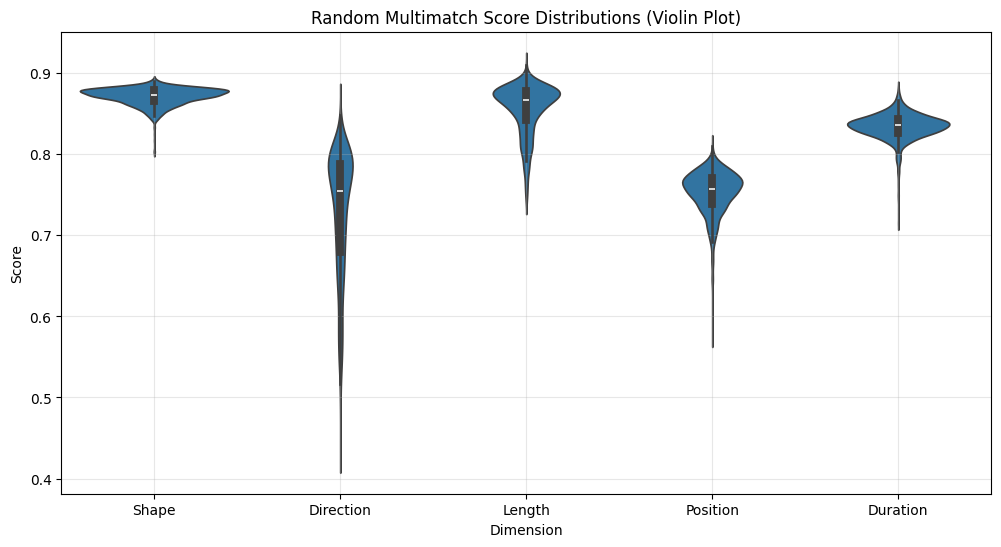

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 6))
melted_df = random_mm_result[dimensions].melt(var_name='Dimension', value_name='Score')
sns.violinplot(data=melted_df, x='Dimension', y='Score')
plt.title('Random Multimatch Score Distributions (Violin Plot)')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()


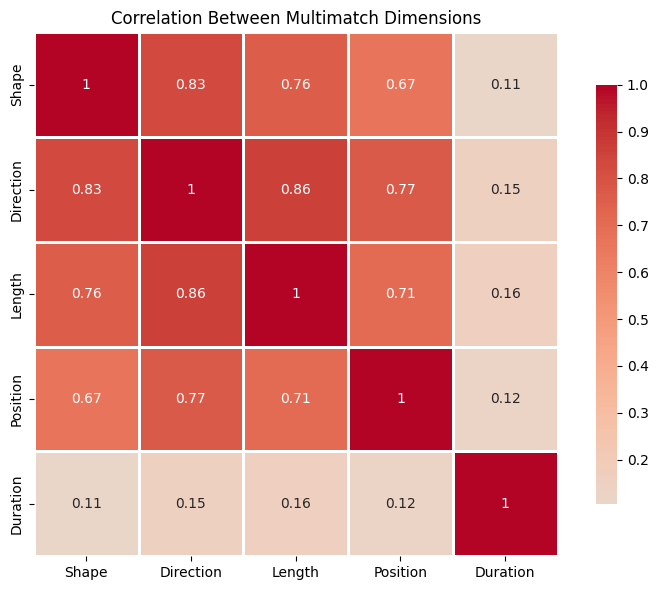

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix = random_mm_result[dimensions].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Multimatch Dimensions')
plt.tight_layout()
plt.show()


             Shape    Direction       Length     Position     Duration
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.871733     0.728301     0.855824     0.752810     0.834425
std       0.010447     0.076737     0.031033     0.026661     0.015993
min       0.802772     0.445737     0.741845     0.575756     0.714982
25%       0.866348     0.679860     0.842714     0.739004     0.826848
50%       0.873684     0.754605     0.866642     0.757457     0.835761
75%       0.879250     0.788590     0.877942     0.770850     0.843394
max       0.890918     0.848480     0.909751     0.810165     0.881550


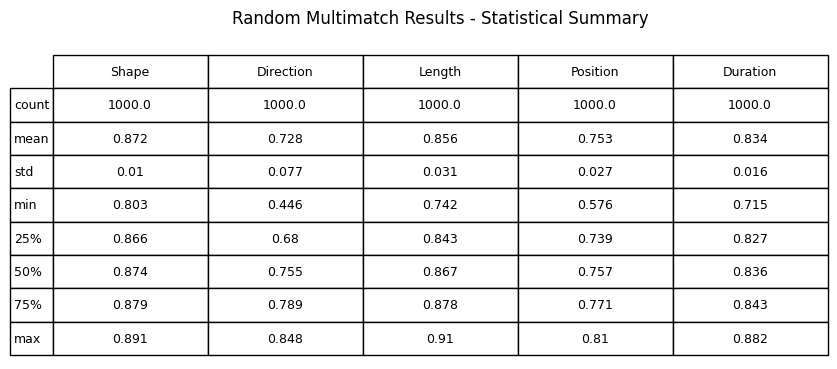

In [ ]:
summary_stats = random_mm_result[dimensions].describe()
print(summary_stats)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_stats.round(3).values,
                rowLabels=summary_stats.index,
                colLabels=summary_stats.columns,
                cellLoc='center',
                loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('Random Multimatch Results - Statistical Summary', pad=20)
plt.show()
